In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)

real_data = np.random.normal(
    loc=5,
    scale=1,
    size=(1000, 2)
).astype('float32')

print("Dataset shape:", real_data.shape)
print(real_data[:5])

Dataset shape: (1000, 2)
[[5.496714  4.861736 ]
 [5.6476884 6.52303  ]
 [4.7658467 4.765863 ]
 [6.5792127 5.7674346]
 [4.5305257 5.54256  ]]


In [3]:
generator = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(2)
])

generator.summary()

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 354 (1.38 KB)

 Trainable params: 354 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
discriminator = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 16)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
loss_function = keras.losses.BinaryCrossentropy()

gen_optimizer = keras.optimizers.Adam(0.001)
disc_optimizer = keras.optimizers.Adam(0.001)

In [6]:
@tf.function
def train_step(real_data):

    noise = tf.random.normal([32, 2])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        fake_data = generator(noise, training=True)

        real_output = discriminator(real_data, training=True)
        fake_output = discriminator(fake_data, training=True)

        gen_loss = loss_function(
            tf.ones_like(fake_output),
            fake_output
        )

        disc_loss = (
            loss_function(tf.ones_like(real_output), real_output)
            +
            loss_function(tf.zeros_like(fake_output), fake_output)
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    gen_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )

    disc_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

In [7]:
dataset = tf.data.Dataset.from_tensor_slices(
    real_data
).shuffle(1000).batch(32)

epochs = 20

for epoch in range(epochs):

    for batch in dataset:
        gen_loss, disc_loss = train_step(batch)

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"Generator Loss: {gen_loss:.4f} - "
        f"Discriminator Loss: {disc_loss:.4f}"
    )

Epoch 1/20 - Generator Loss: 0.6684 - Discriminator Loss: 1.2063
Epoch 2/20 - Generator Loss: 0.6776 - Discriminator Loss: 1.0784
Epoch 3/20 - Generator Loss: 0.6756 - Discriminator Loss: 0.9445
Epoch 4/20 - Generator Loss: 0.6437 - Discriminator Loss: 0.9793
Epoch 5/20 - Generator Loss: 0.6466 - Discriminator Loss: 1.1795
Epoch 6/20 - Generator Loss: 0.5780 - Discriminator Loss: 1.4937
Epoch 7/20 - Generator Loss: 0.7916 - Discriminator Loss: 1.4717
Epoch 8/20 - Generator Loss: 0.9425 - Discriminator Loss: 1.4528
Epoch 9/20 - Generator Loss: 0.9453 - Discriminator Loss: 1.3960
Epoch 10/20 - Generator Loss: 0.9429 - Discriminator Loss: 1.3469
Epoch 11/20 - Generator Loss: 0.6834 - Discriminator Loss: 1.5134
Epoch 12/20 - Generator Loss: 0.8265 - Discriminator Loss: 1.1226
Epoch 13/20 - Generator Loss: 0.6785 - Discriminator Loss: 1.2077
Epoch 14/20 - Generator Loss: 0.6876 - Discriminator Loss: 1.7506
Epoch 15/20 - Generator Loss: 0.7495 - Discriminator Loss: 1.6379
Epoch 16/20 - Gener

In [8]:
noise = tf.random.normal([100, 2])

generated_data = generator(
    noise,
    training=False
).numpy()

print("Generated Data:")
print(generated_data[:5])

Generated Data:
[[8.798529  4.9713974]
 [4.702888  3.3517106]
 [5.492979  3.8557303]
 [6.3626275 4.0075994]
 [5.658622  3.2061746]]


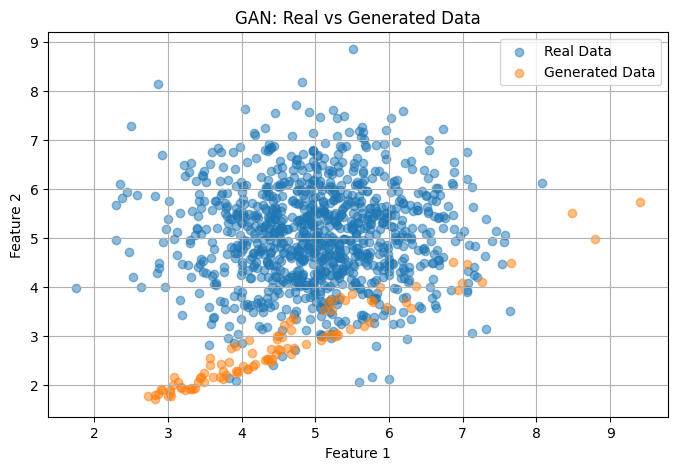

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    real_data[:, 0],
    real_data[:, 1],
    label='Real Data',
    alpha=0.5
)

plt.scatter(
    generated_data[:, 0],
    generated_data[:, 1],
    label='Generated Data',
    alpha=0.5
)

plt.title("GAN: Real vs Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()